# Chicago Crime Analytics — Geographic and Hotspot Analysis

This notebook analyzes geographic distributions in 761,563 official
Chicago reported-incident records covering the complete calendar years
2023–2025.

**Interpretation contract:** administrative-area results are incident
volumes, not population-normalized crime rates or measures of individual
risk. Coordinate-density figures are descriptive aggregations of
map-eligible records, not statistically significant hotspot tests. No
spatial significance method, exposure denominator, or causal model is
applied.

## 1. Environment and secure read-only connection

Connection settings come from environment variables or a Git-ignored
`.env`. Credentials and connection URLs are not displayed. Every
PostgreSQL transaction is forced to read-only mode.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import display
from sqlalchemy import URL, create_engine, text

%matplotlib inline


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / ".env.example").exists() and (candidate / "sql").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = find_project_root()
load_dotenv(PROJECT_ROOT / ".env", override=False)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Project root located from the current working directory.")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__} | Matplotlib: {plt.matplotlib.__version__}")

Project root located from the current working directory.
Pandas: 2.3.3 | NumPy: 2.0.2 | Matplotlib: 3.9.4


In [2]:
def build_read_only_engine():
    host = os.getenv("POSTGRES_HOST") or None
    user = os.getenv("POSTGRES_USER") or None
    password = os.getenv("POSTGRES_PASSWORD") or None
    database = os.getenv("POSTGRES_DB", "chicago_crime")
    port = int(os.getenv("POSTGRES_PORT", "5432")) if host else None
    url = URL.create(
        "postgresql+psycopg",
        username=user,
        password=password,
        host=host,
        port=port,
        database=database,
    )
    connect_args = {"options": "-c default_transaction_read_only=on"}
    sslmode = os.getenv("POSTGRES_SSLMODE")
    if host and sslmode:
        connect_args["sslmode"] = sslmode
    return create_engine(url, future=True, connect_args=connect_args), database, host


engine, database_name, database_host = build_read_only_engine()
with engine.connect() as connection:
    connection_check = pd.read_sql_query(
        text("""
            SELECT current_database() AS database_name,
                   current_setting('transaction_read_only') AS transaction_read_only
        """),
        connection,
    )
assert connection_check.loc[0, "transaction_read_only"] == "on"
print(
    f"Connected securely to {database_name} via "
    f"{'configured host' if database_host else 'local PostgreSQL socket'}; transactions are read-only."
)
display(connection_check)

Connected securely to chicago_crime via local PostgreSQL socket; transactions are read-only.


,database_name,transaction_read_only
0,chicago_crime,on


## 2. Load canonical geographic fields and SQL benchmarks

Pandas calculations use record-level fields from
`clean_chicago_crimes`. Existing views provide the official community
names, executive denominators, community-area comparison benchmarks,
and coordinate-eligible point count.

In [3]:
records = pd.read_sql_query(
    text("""
        SELECT source_id,
               crime_date,
               crime_year,
               hour_of_day,
               time_of_day,
               primary_type,
               location_description,
               district,
               district_current_flag,
               community_area,
               community_area_eligible_flag,
               coordinate_mappable_flag,
               latitude,
               longitude
        FROM public.clean_chicago_crimes
        ORDER BY source_id
    """),
    engine,
    parse_dates=["crime_date"],
)
community_lookup = pd.read_sql_query(
    text("SELECT * FROM public.vw_community_area_lookup ORDER BY community_area"), engine
)
sql_kpis = pd.read_sql_query(text("SELECT * FROM public.vw_executive_kpis"), engine)
sql_area_yoy = pd.read_sql_query(
    text("SELECT * FROM public.vw_community_area_yoy ORDER BY current_year, community_area"),
    engine,
)
sql_geographic_count = int(pd.read_sql_query(
    text("SELECT COUNT(*)::bigint AS row_count FROM public.vw_geographic_crime_points"),
    engine,
).loc[0, "row_count"])

records["crime_year"] = pd.to_numeric(records["crime_year"], errors="raise")
records["hour_of_day"] = pd.to_numeric(records["hour_of_day"], errors="raise")
records["latitude"] = pd.to_numeric(records["latitude"], errors="coerce")
records["longitude"] = pd.to_numeric(records["longitude"], errors="coerce")

print(f"Loaded {len(records):,} records and {records['source_id'].nunique():,} unique source IDs.")
print(f"Date coverage: {records['crime_date'].min().date()} through {records['crime_date'].max().date()}")
display(records.head(3))

Loaded 761,563 records and 761,563 unique source IDs.
Date coverage: 2023-01-01 through 2025-12-31


,source_id,crime_date,crime_year,hour_of_day,time_of_day,primary_type,location_description,district,district_current_flag,community_area,community_area_eligible_flag,coordinate_mappable_flag,latitude,longitude
0,27279,2023-01-01,2023,5,Overnight,HOMICIDE,TAVERN,012,True,24.0000,True,True,41.9031,-87.6806
1,27280,2023-01-01,2023,4,Overnight,HOMICIDE,STREET,009,True,60.0000,True,True,41.8244,-87.6411
2,27281,2023-01-01,2023,9,Morning,HOMICIDE,STREET,005,True,49.0000,True,True,41.7005,-87.6233


In [4]:
FIGURE_DIR = PROJECT_ROOT / "images" / "python"
EXPORT_DIR = PROJECT_ROOT / "data" / "processed" / "tableau_geographic"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

BLUE = "#1f77b4"
ORANGE = "#ff7f0e"
GREEN = "#2ca02c"
RED = "#d62728"
PURPLE = "#9467bd"
GRAY = "#6b7280"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(fig, filename, note="Counts are descriptive, not population-normalized rates."):
    path = FIGURE_DIR / filename
    fig.text(
        0.01,
        0.01,
        "Source: City of Chicago Crimes - 2001 to Present (ijzp-q8t2); "
        f"complete years 2023-2025. {note}",
        ha="left",
        fontsize=7.2,
        color=GRAY,
    )
    fig.tight_layout(rect=[0, 0.055, 1, 1])
    fig.savefig(path, dpi=160, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"Saved {path.relative_to(PROJECT_ROOT)}")

## 3. Geographic coverage and missingness

Community-area eligibility and coordinate mapping are separate measures.
Missing coordinates do not make an incident unusable for administrative,
temporal, category, arrest, or domestic analysis.

,geographic_measure,eligible_count,excluded_count,coverage_percentage
0,Community-area ID,760496,1067,99.8599
1,Coordinate mapping,754866,6697,99.1206


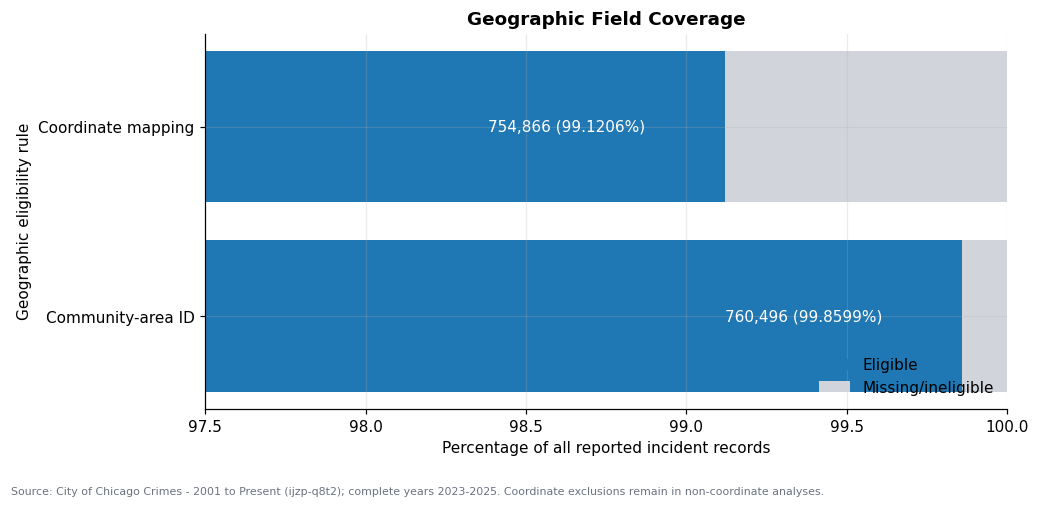

Saved images/python/python_geographic_coverage.png


In [5]:
total_records = len(records)
coordinate_mappable_count = int(records["coordinate_mappable_flag"].sum())
coordinate_missing_or_ineligible_count = total_records - coordinate_mappable_count
community_eligible_count = int(records["community_area_eligible_flag"].sum())
community_ineligible_count = total_records - community_eligible_count

coverage = pd.DataFrame({
    "geographic_measure": ["Community-area ID", "Coordinate mapping"],
    "eligible_count": [community_eligible_count, coordinate_mappable_count],
    "excluded_count": [community_ineligible_count, coordinate_missing_or_ineligible_count],
})
coverage["coverage_percentage"] = 100.0 * coverage["eligible_count"] / total_records
display(coverage.round(4))

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.barh(coverage["geographic_measure"], coverage["coverage_percentage"], color=BLUE, label="Eligible")
ax.barh(
    coverage["geographic_measure"],
    100 - coverage["coverage_percentage"],
    left=coverage["coverage_percentage"],
    color="#d1d5db",
    label="Missing/ineligible",
)
for index, row in coverage.iterrows():
    ax.text(row["coverage_percentage"] - 0.25, index,
            f"{row['eligible_count']:,} ({row['coverage_percentage']:.4f}%)",
            va="center", ha="right", color="white", fontsize=10)
ax.set_xlim(97.5, 100)
ax.set_title("Geographic Field Coverage")
ax.set_xlabel("Percentage of all reported incident records")
ax.set_ylabel("Geographic eligibility rule")
ax.legend(frameon=False, loc="lower right")
save_figure(
    fig,
    "python_geographic_coverage.png",
    note="Coordinate exclusions remain in non-coordinate analyses.",
)

## 4. Incident volume by community area and district

,community_area,reported_incident_count,community_area_name,percentage_of_eligible_area_records,volume_rank
24,25.0000,37464,AUSTIN,4.9263,1
7,8.0000,33810,NEAR NORTH SIDE,4.4458,2
27,28.0000,31729,NEAR WEST SIDE,4.1721,3
31,32.0000,26725,LOOP,3.5142,4
42,43.0000,25447,SOUTH SHORE,3.3461,5
23,24.0000,22923,WEST TOWN,3.0142,6
22,23.0000,20212,HUMBOLDT PARK,2.6577,7
28,29.0000,20185,NORTH LAWNDALE,2.6542,8
70,71.0000,19657,AUBURN GRESHAM,2.5848,9
5,6.0000,19426,LAKE VIEW,2.5544,10


,district,district_current_flag,reported_incident_count,percentage_of_all_records,volume_rank
7,008,True,49610,6.5142,1
11,012,True,47142,6.1902,2
5,006,True,44341,5.8224,3
0,001,True,43013,5.6480,4
3,004,True,41894,5.5011,5
10,011,True,41074,5.3934,6
17,019,True,40467,5.3137,7
16,018,True,40171,5.2748,8
1,002,True,39525,5.1900,9
2,003,True,39166,5.1428,10


District code 061 retained as unmatched to the current reference: 1,020 records.


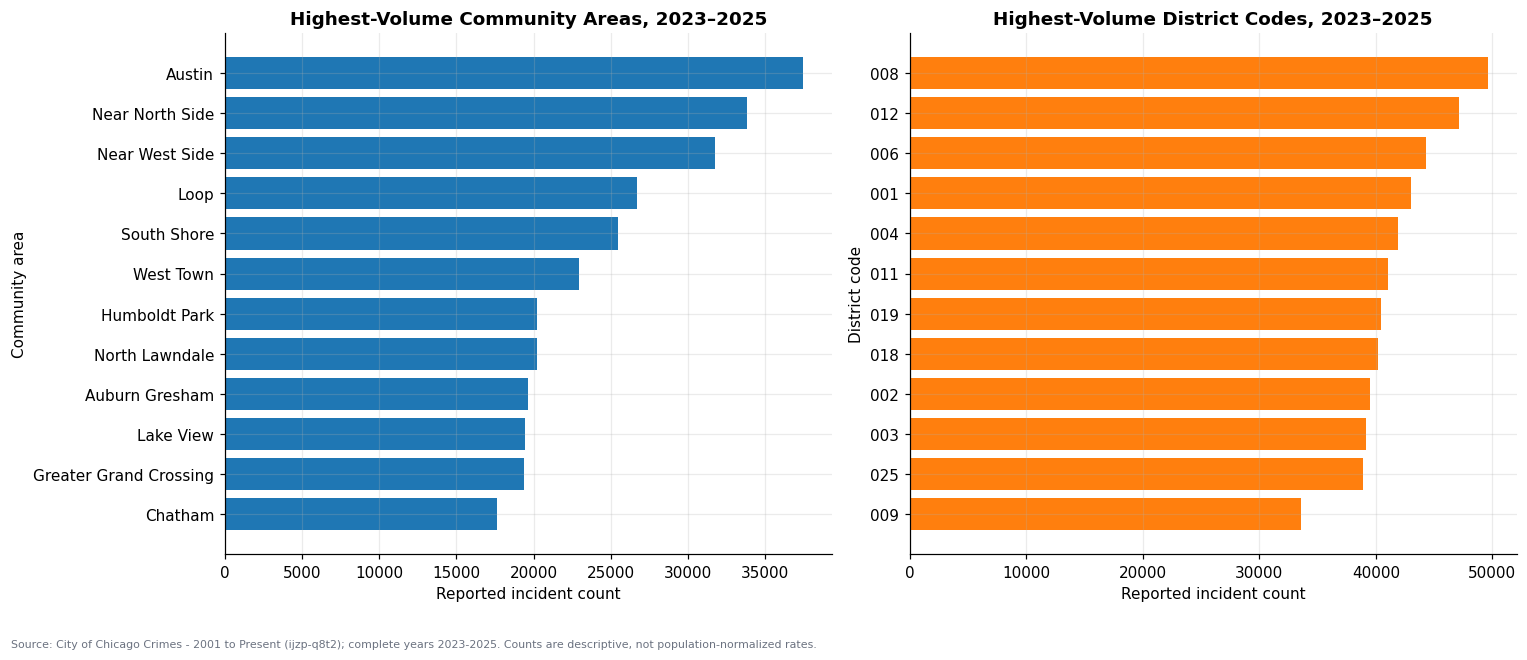

Saved images/python/python_geographic_area_volume.png


In [6]:
community_counts = (
    records.loc[records["community_area_eligible_flag"]]
    .groupby("community_area", as_index=False)
    .size()
    .rename(columns={"size": "reported_incident_count"})
    .merge(community_lookup, on="community_area", validate="one_to_one")
)
community_counts["percentage_of_eligible_area_records"] = (
    100.0 * community_counts["reported_incident_count"] / community_eligible_count
)
community_counts["volume_rank"] = (
    community_counts["reported_incident_count"].rank(method="min", ascending=False).astype(int)
)
community_counts = community_counts.sort_values(["volume_rank", "community_area"])

district_counts = (
    records.groupby(["district", "district_current_flag"], as_index=False)
    .size()
    .rename(columns={"size": "reported_incident_count"})
)
district_counts["percentage_of_all_records"] = (
    100.0 * district_counts["reported_incident_count"] / total_records
)
district_counts["volume_rank"] = (
    district_counts["reported_incident_count"].rank(method="min", ascending=False).astype(int)
)
district_counts = district_counts.sort_values(["volume_rank", "district"])

display(community_counts.head(15).round(4))
display(district_counts.head(15).round(4))
print(
    f"District code 061 retained as unmatched to the current reference: "
    f"{int(district_counts.loc[district_counts['district'].eq('061'), 'reported_incident_count'].iloc[0]):,} records."
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_communities = community_counts.head(12).sort_values("reported_incident_count")
top_districts = district_counts.head(12).sort_values("reported_incident_count")
axes[0].barh(top_communities["community_area_name"].str.title(),
             top_communities["reported_incident_count"], color=BLUE)
axes[0].set_title("Highest-Volume Community Areas, 2023–2025")
axes[0].set_xlabel("Reported incident count")
axes[0].set_ylabel("Community area")
axes[1].barh(top_districts["district"], top_districts["reported_incident_count"], color=ORANGE)
axes[1].set_title("Highest-Volume District Codes, 2023–2025")
axes[1].set_xlabel("Reported incident count")
axes[1].set_ylabel("District code")
save_figure(fig, "python_geographic_area_volume.png")

**Interpretation:** These rankings show administrative-area incident
volume only. They do not adjust for population, area, commuters,
visitors, land use, or other exposure and therefore are not risk ranks.

## 5. Crime-category geographic concentration

,primary_type,eligible_category_count,leading_community_area,leading_area_count,leading_area_share_pct,top_five_area_share_pct
0,THEFT,173260,NEAR NORTH SIDE,13423,7.7473,28.1744
6,DECEPTIVE PRACTICE,49345,NEAR NORTH SIDE,3689,7.4759,25.3156
9,WEAPONS VIOLATION,21893,AUSTIN,1411,6.4450,23.4230
7,ROBBERY,25969,AUSTIN,1698,6.5386,22.6462
8,BURGLARY,25671,WEST TOWN,1338,5.2121,20.7043
1,BATTERY,133043,AUSTIN,8030,6.0356,20.4513
3,MOTOR VEHICLE THEFT,68216,AUSTIN,3207,4.7012,19.9601
4,ASSAULT,67717,AUSTIN,3749,5.5363,19.9374
2,CRIMINAL DAMAGE,84896,AUSTIN,4051,4.7717,18.9974
5,OTHER OFFENSE,49722,AUSTIN,2593,5.2150,17.9920


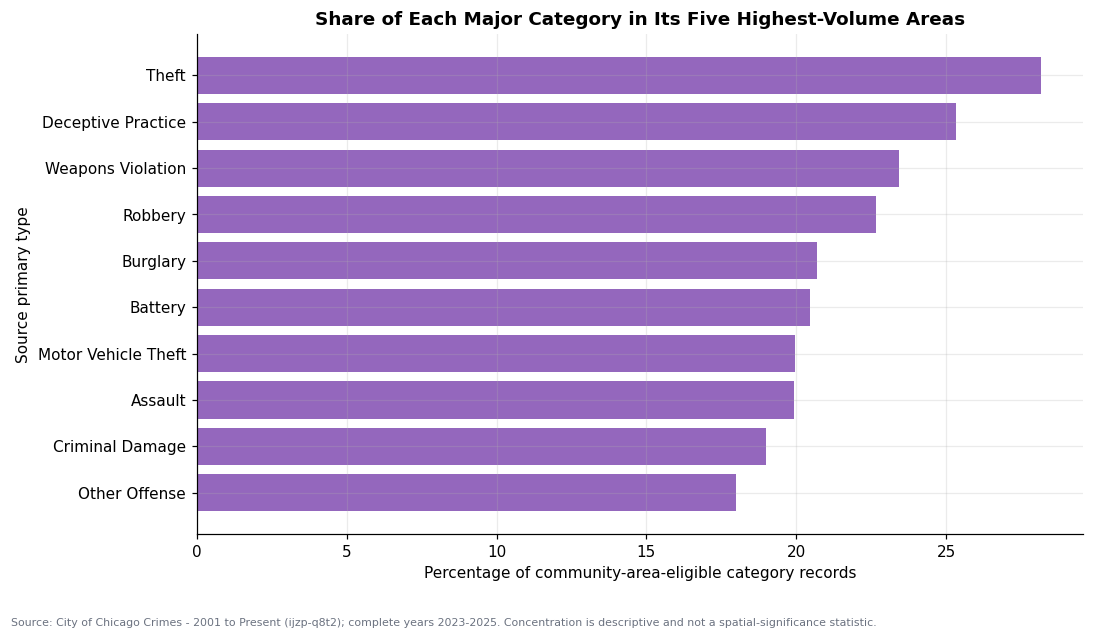

Saved images/python/python_category_geographic_concentration.png


In [7]:
category_totals = records["primary_type"].value_counts()
major_categories = category_totals.head(10).index.tolist()
category_area = (
    records.loc[
        records["community_area_eligible_flag"]
        & records["primary_type"].isin(major_categories)
    ]
    .groupby(["primary_type", "community_area"], as_index=False)
    .size()
    .rename(columns={"size": "reported_incident_count"})
    .merge(community_lookup, on="community_area", validate="many_to_one")
)
category_area["category_eligible_total"] = (
    category_area.groupby("primary_type")["reported_incident_count"].transform("sum")
)
category_area["category_area_rank"] = (
    category_area.groupby("primary_type")["reported_incident_count"]
    .rank(method="min", ascending=False)
)

concentration_rows = []
for category in major_categories:
    group = category_area.loc[category_area["primary_type"].eq(category)].sort_values(
        ["reported_incident_count", "community_area"], ascending=[False, True]
    )
    concentration_rows.append({
        "primary_type": category,
        "eligible_category_count": int(group["category_eligible_total"].iloc[0]),
        "leading_community_area": group.iloc[0]["community_area_name"],
        "leading_area_count": int(group.iloc[0]["reported_incident_count"]),
        "leading_area_share_pct": 100.0 * group.iloc[0]["reported_incident_count"] / group.iloc[0]["category_eligible_total"],
        "top_five_area_share_pct": 100.0 * group.head(5)["reported_incident_count"].sum() / group.iloc[0]["category_eligible_total"],
    })
concentration = pd.DataFrame(concentration_rows).sort_values(
    "top_five_area_share_pct", ascending=False
)
display(concentration.round(4))

fig, ax = plt.subplots(figsize=(10, 5.8))
plot_data = concentration.sort_values("top_five_area_share_pct")
ax.barh(plot_data["primary_type"].str.title(), plot_data["top_five_area_share_pct"], color=PURPLE)
ax.set_title("Share of Each Major Category in Its Five Highest-Volume Areas")
ax.set_xlabel("Percentage of community-area-eligible category records")
ax.set_ylabel("Source primary type")
save_figure(
    fig,
    "python_category_geographic_concentration.png",
    note="Concentration is descriptive and not a spatial-significance statistic.",
)

**Interpretation:** A larger top-five share means more of that category's
eligible records were concentrated in five community areas. It does not
measure population risk, clustering significance, or causal exposure.

## 6. Annual geographic changes

,community_area,community_area_name,previous_year_count,reported_incident_count,absolute_change,percentage_change
178,25,AUSTIN,"12,958.0000",11806,"-1,152.0000",-8.8903
177,24,WEST TOWN,"8,011.0000",6887,"-1,124.0000",-14.0307
175,22,LOGAN SQUARE,"5,459.0000",4533,-926.0000,-16.9628
176,23,HUMBOLDT PARK,"7,052.0000",6162,-890.0000,-12.6205
159,6,LAKE VIEW,"6,833.0000",6024,-809.0000,-11.8396
172,19,BELMONT CRAGIN,"4,727.0000",3946,-781.0000,-16.5221
185,32,LOOP,"9,331.0000",8584,-747.0000,-8.0056
181,28,NEAR WEST SIDE,"10,979.0000",10326,-653.0000,-5.9477
154,1,ROGERS PARK,"4,354.0000",3768,-586.0000,-13.4589
219,66,CHICAGO LAWN,"5,315.0000",4751,-564.0000,-10.6115


,crime_year,district,district_current_flag,reported_incident_count,citywide_count,percentage_of_year,annual_volume_rank,previous_year_count,absolute_change,percentage_change
55,2025,008,True,15278,238086,6.4170,1,"17,289.0000","-2,011.0000",-11.6317
60,2025,014,True,8060,238086,3.3853,17,"9,902.0000","-1,842.0000",-18.6023
69,2025,025,True,11596,238086,4.8705,11,"13,287.0000","-1,691.0000",-12.7267
65,2025,019,True,12577,238086,5.2825,10,"14,132.0000","-1,555.0000",-11.0034
59,2025,012,True,14941,238086,6.2755,2,"16,215.0000","-1,274.0000",-7.8569
53,2025,006,True,13609,238086,5.7160,4,"14,876.0000","-1,267.0000",-8.5171
68,2025,024,True,7637,238086,3.2077,20,"8,832.0000","-1,195.0000",-13.5303
48,2025,001,True,13724,238086,5.7643,3,"14,915.0000","-1,191.0000",-7.9852
57,2025,010,True,9529,238086,4.0023,14,"10,562.0000","-1,033.0000",-9.7803
62,2025,016,True,8137,238086,3.4177,16,"9,093.0000",-956.0000,-10.5136


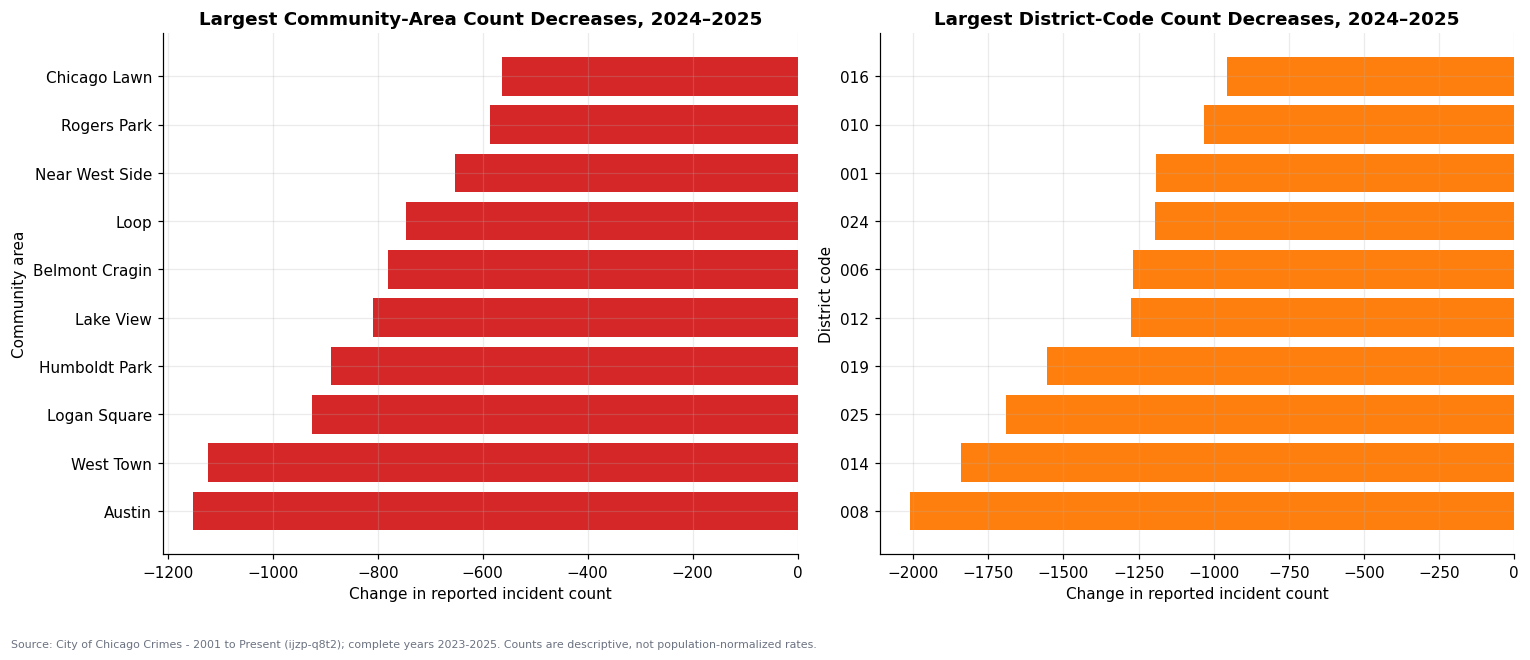

Saved images/python/python_annual_geographic_changes.png


In [8]:
years = np.sort(records["crime_year"].unique())
area_grid = pd.MultiIndex.from_product(
    [years, community_lookup["community_area"].astype(int)],
    names=["crime_year", "community_area"],
).to_frame(index=False)
area_year = (
    records.loc[records["community_area_eligible_flag"]]
    .groupby(["crime_year", "community_area"], as_index=False)
    .size()
    .rename(columns={"size": "reported_incident_count"})
)
area_year = (
    area_grid.merge(area_year, on=["crime_year", "community_area"], how="left")
    .merge(community_lookup, on="community_area", validate="many_to_one")
    .sort_values(["community_area", "crime_year"])
)
area_year["reported_incident_count"] = area_year["reported_incident_count"].fillna(0).astype(int)
area_year["eligible_area_year_total"] = area_year.groupby("crime_year")["reported_incident_count"].transform("sum")
area_year["percentage_of_eligible_year"] = (
    100.0 * area_year["reported_incident_count"] / area_year["eligible_area_year_total"]
)
area_year["annual_volume_rank"] = (
    area_year.groupby("crime_year")["reported_incident_count"]
    .rank(method="min", ascending=False).astype(int)
)
area_year["previous_year_count"] = area_year.groupby("community_area")["reported_incident_count"].shift(1)
area_year["absolute_change"] = area_year["reported_incident_count"] - area_year["previous_year_count"]
area_year["percentage_change"] = np.where(
    area_year["previous_year_count"].eq(0),
    np.nan,
    100.0 * area_year["absolute_change"] / area_year["previous_year_count"],
)

district_year = (
    records.groupby(["crime_year", "district", "district_current_flag"], as_index=False)
    .size()
    .rename(columns={"size": "reported_incident_count"})
    .sort_values(["district", "crime_year"])
)
district_year["citywide_count"] = district_year.groupby("crime_year")["reported_incident_count"].transform("sum")
district_year["percentage_of_year"] = 100.0 * district_year["reported_incident_count"] / district_year["citywide_count"]
district_year["annual_volume_rank"] = (
    district_year.groupby("crime_year")["reported_incident_count"]
    .rank(method="min", ascending=False).astype(int)
)
district_year["previous_year_count"] = district_year.groupby("district")["reported_incident_count"].shift(1)
district_year["absolute_change"] = district_year["reported_incident_count"] - district_year["previous_year_count"]
district_year["percentage_change"] = np.where(
    district_year["previous_year_count"].eq(0),
    np.nan,
    100.0 * district_year["absolute_change"] / district_year["previous_year_count"],
)

area_change_2025 = area_year.loc[area_year["crime_year"].eq(2025)].copy()
district_change_2025 = district_year.loc[district_year["crime_year"].eq(2025)].copy()
display(area_change_2025.nsmallest(10, "absolute_change")[[
    "community_area", "community_area_name", "previous_year_count",
    "reported_incident_count", "absolute_change", "percentage_change"
]].round(4))
display(district_change_2025.sort_values("absolute_change").head(10).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
area_plot = area_change_2025.nsmallest(10, "absolute_change").sort_values("absolute_change")
district_plot = district_change_2025.nsmallest(10, "absolute_change").sort_values("absolute_change")
axes[0].barh(area_plot["community_area_name"].str.title(), area_plot["absolute_change"], color=RED)
axes[0].set_title("Largest Community-Area Count Decreases, 2024–2025")
axes[0].set_xlabel("Change in reported incident count")
axes[0].set_ylabel("Community area")
axes[1].barh(district_plot["district"], district_plot["absolute_change"], color=ORANGE)
axes[1].set_title("Largest District-Code Count Decreases, 2024–2025")
axes[1].set_xlabel("Change in reported incident count")
axes[1].set_ylabel("District code")
save_figure(fig, "python_annual_geographic_changes.png")

## 7. Persistent high-volume community areas

,community_area,community_area_name,years_in_top_10,years_in_top_20,average_annual_rank,three_year_incident_count
24,25,AUSTIN,3,3,1.0000,37464
7,8,NEAR NORTH SIDE,3,3,2.0000,33810
27,28,NEAR WEST SIDE,3,3,3.0000,31729
31,32,LOOP,3,3,4.0000,26725
42,43,SOUTH SHORE,3,3,5.0000,25447
23,24,WEST TOWN,3,3,6.0000,22923
22,23,HUMBOLDT PARK,3,3,7.6700,20212
28,29,NORTH LAWNDALE,3,3,8.0000,20185
70,71,AUBURN GRESHAM,3,3,9.0000,19657
68,69,GREATER GRAND CROSSING,2,3,10.3300,19393


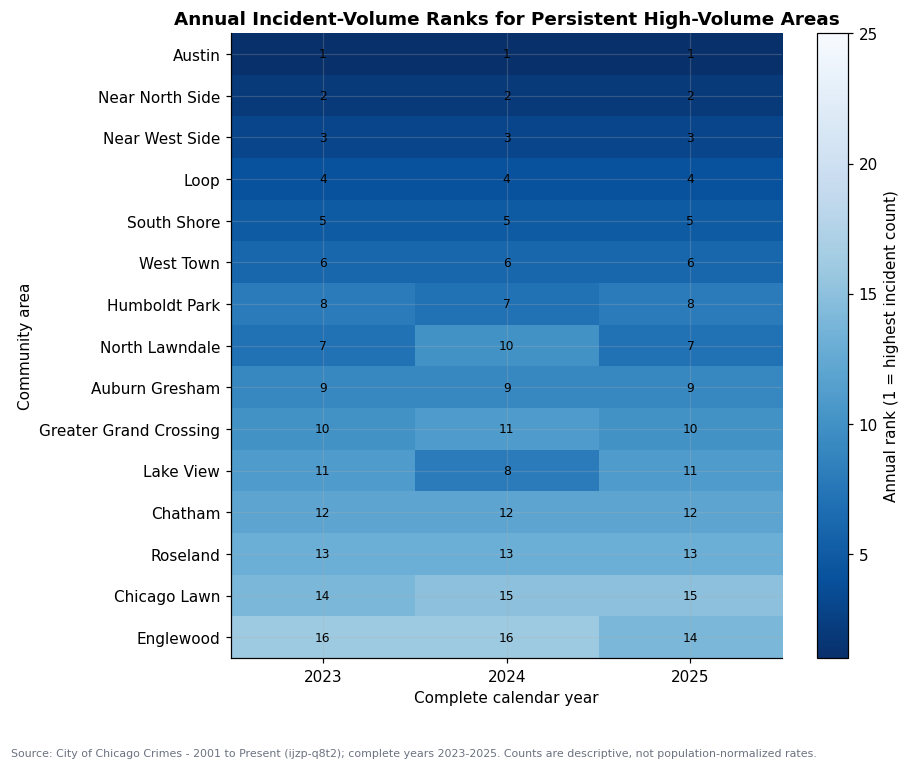

Saved images/python/python_persistent_high_volume_areas.png


In [9]:
persistence = (
    area_year.groupby(["community_area", "community_area_name"], as_index=False)
    .agg(
        years_in_top_10=("annual_volume_rank", lambda values: int((values <= 10).sum())),
        years_in_top_20=("annual_volume_rank", lambda values: int((values <= 20).sum())),
        average_annual_rank=("annual_volume_rank", "mean"),
        three_year_incident_count=("reported_incident_count", "sum"),
    )
    .sort_values(
        ["years_in_top_10", "years_in_top_20", "three_year_incident_count"],
        ascending=[False, False, False],
    )
)
display(persistence.head(20).round(2))

persistent_areas = persistence.head(15)["community_area"].tolist()
rank_matrix = (
    area_year.loc[area_year["community_area"].isin(persistent_areas)]
    .pivot(index="community_area_name", columns="crime_year", values="annual_volume_rank")
    .reindex(persistence.head(15)["community_area_name"])
)
fig, ax = plt.subplots(figsize=(8.5, 7))
image = ax.imshow(rank_matrix.to_numpy(), aspect="auto", cmap="Blues_r", vmin=1, vmax=25)
ax.set_title("Annual Incident-Volume Ranks for Persistent High-Volume Areas")
ax.set_xlabel("Complete calendar year")
ax.set_ylabel("Community area")
ax.set_xticks(np.arange(len(rank_matrix.columns)), labels=rank_matrix.columns)
ax.set_yticks(np.arange(len(rank_matrix.index)), labels=[name.title() for name in rank_matrix.index])
for row in range(rank_matrix.shape[0]):
    for column in range(rank_matrix.shape[1]):
        ax.text(column, row, f"{int(rank_matrix.iloc[row, column])}",
                ha="center", va="center", fontsize=8)
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Annual rank (1 = highest incident count)")
save_figure(fig, "python_persistent_high_volume_areas.png")

**Interpretation:** Persistence means an area repeatedly had a high
reported-incident count rank. It does not imply a persistently high
population-normalized rate or individual-level risk.

## 8. Location-description temporal patterns

,location_description,leading_time_of_day,leading_share_pct,reported_incident_count
location_description,,,,
STREET,STREET,Evening,34.7047,209744
APARTMENT,APARTMENT,Afternoon,29.2775,145962
RESIDENCE,RESIDENCE,Afternoon,31.1040,91805
SIDEWALK,SIDEWALK,Afternoon,34.6791,38937
PARKING LOT / GARAGE (NON RESIDENTIAL),PARKING LOT / GARAGE (NON RESIDENTIAL),Afternoon,33.1176,27197
SMALL RETAIL STORE,SMALL RETAIL STORE,Afternoon,45.2244,26070
ALLEY,ALLEY,Evening,33.1682,17360
RESTAURANT,RESTAURANT,Afternoon,38.0382,17046
DEPARTMENT STORE,DEPARTMENT STORE,Afternoon,51.0041,15536


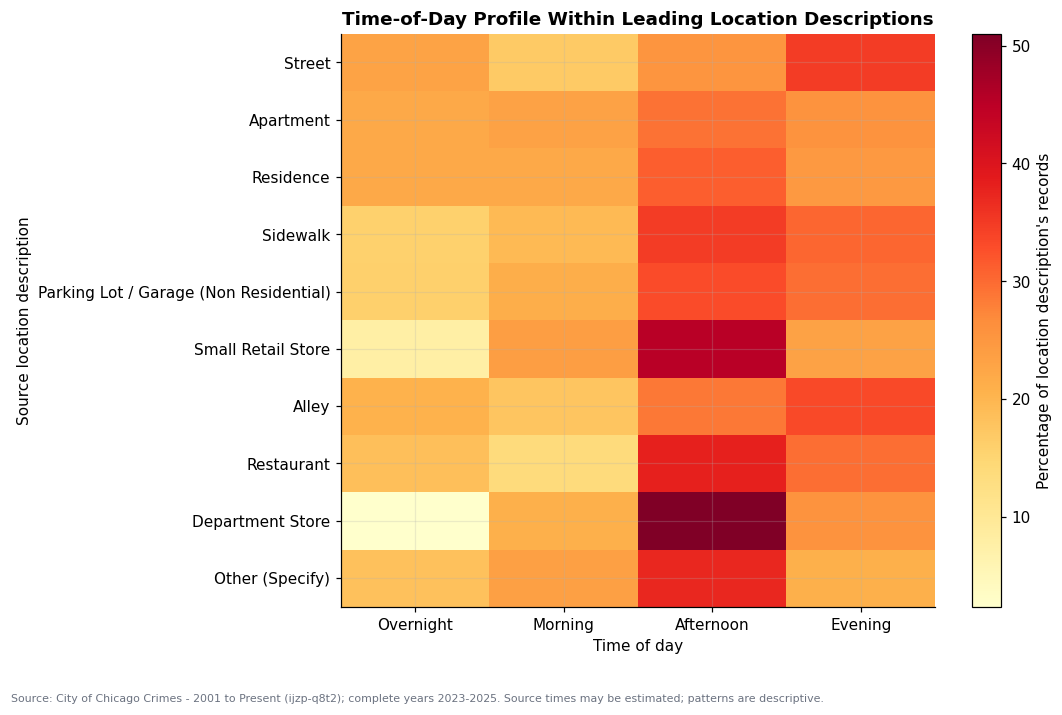

Saved images/python/python_location_temporal_patterns.png


In [10]:
time_order = ["Overnight", "Morning", "Afternoon", "Evening"]
leading_locations = records["location_description"].value_counts().head(10).index.tolist()
location_time = (
    records.loc[records["location_description"].isin(leading_locations)]
    .groupby(["location_description", "time_of_day"], as_index=False)
    .size()
    .rename(columns={"size": "reported_incident_count"})
)
location_time["location_total"] = (
    location_time.groupby("location_description")["reported_incident_count"].transform("sum")
)
location_time["percentage_of_location_total"] = (
    100.0 * location_time["reported_incident_count"] / location_time["location_total"]
)
time_profile = (
    location_time.pivot(
        index="location_description", columns="time_of_day", values="percentage_of_location_total"
    )
    .reindex(index=leading_locations, columns=time_order)
)
peak_time = pd.DataFrame({
    "location_description": time_profile.index,
    "leading_time_of_day": time_profile.idxmax(axis=1),
    "leading_share_pct": time_profile.max(axis=1).to_numpy(),
    "reported_incident_count": [int(records["location_description"].eq(location).sum()) for location in time_profile.index],
})
display(peak_time.round(4))

fig, ax = plt.subplots(figsize=(10, 6.5))
image = ax.imshow(time_profile.to_numpy(), aspect="auto", cmap="YlOrRd")
ax.set_title("Time-of-Day Profile Within Leading Location Descriptions")
ax.set_xlabel("Time of day")
ax.set_ylabel("Source location description")
ax.set_xticks(np.arange(len(time_order)), labels=time_order)
ax.set_yticks(np.arange(len(time_profile.index)), labels=[name.title() for name in time_profile.index])
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Percentage of location description's records")
save_figure(
    fig,
    "python_location_temporal_patterns.png",
    note="Source times may be estimated; patterns are descriptive.",
)

## 9. Coordinate-level descriptive density

,crime_year,latitude_bin_center,longitude_bin_center,reported_incident_count
437,2023,41.8850,-87.6250,3979
454,2023,41.8950,-87.6250,3863
420,2023,41.8750,-87.6250,2006
173,2023,41.7450,-87.6050,1750
453,2023,41.8950,-87.6350,1745
436,2023,41.8850,-87.6350,1690
198,2023,41.7550,-87.5650,1587
605,2023,41.9650,-87.6550,1540
393,2023,41.8650,-87.7150,1489
445,2023,41.8950,-87.7150,1483


Coordinate-eligible records summarized: 754,866
Year-grid rows: 2,127


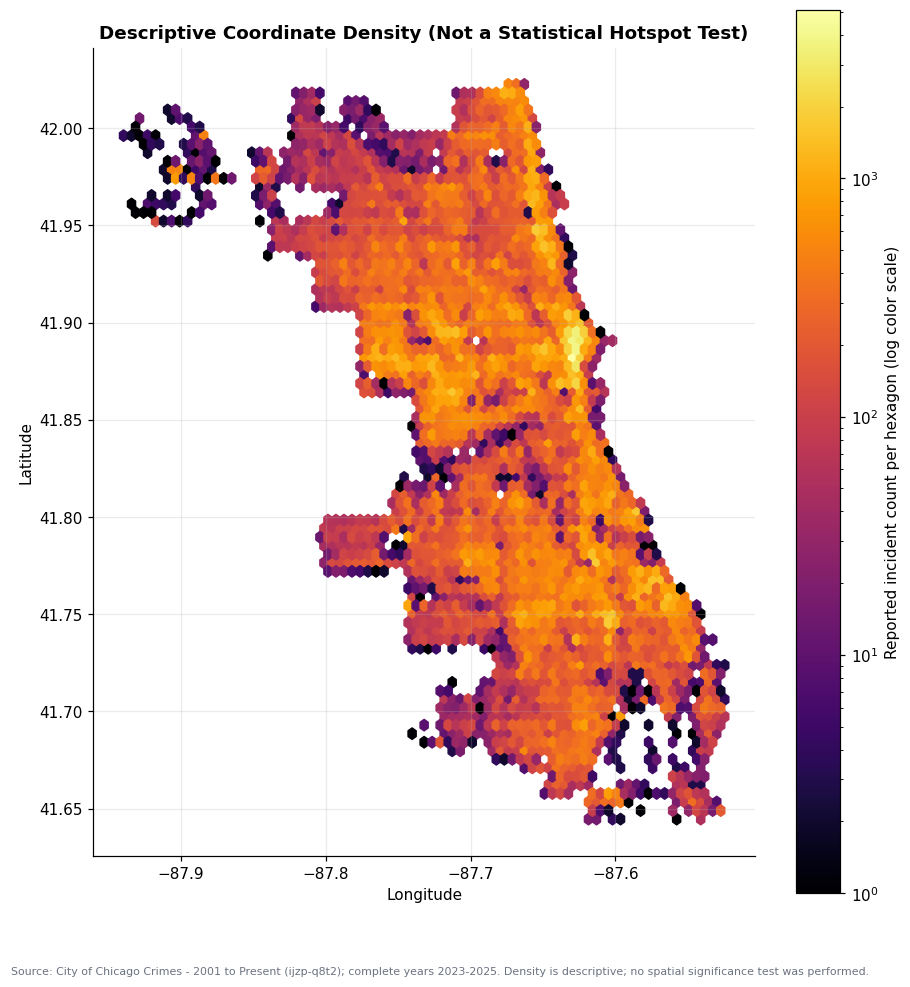

Saved images/python/python_coordinate_density.png


In [11]:
coordinate_records = records.loc[records["coordinate_mappable_flag"]].copy()
assert coordinate_records[["latitude", "longitude"]].notna().all().all()

# Approximate display grid: 0.01 degrees is roughly 0.8-1.1 km across
# Chicago. It is not equal-area and is not used for statistical inference.
coordinate_records["latitude_bin_center"] = (
    np.floor(coordinate_records["latitude"] / 0.01) * 0.01 + 0.005
).round(3)
coordinate_records["longitude_bin_center"] = (
    np.floor(coordinate_records["longitude"] / 0.01) * 0.01 + 0.005
).round(3)
density_grid = (
    coordinate_records.groupby(
        ["crime_year", "latitude_bin_center", "longitude_bin_center"], as_index=False
    )
    .size()
    .rename(columns={"size": "reported_incident_count"})
    .sort_values(["crime_year", "reported_incident_count"], ascending=[True, False])
)
display(density_grid.head(10))
print(f"Coordinate-eligible records summarized: {len(coordinate_records):,}")
print(f"Year-grid rows: {len(density_grid):,}")

fig, ax = plt.subplots(figsize=(8.5, 9))
density = ax.hexbin(
    coordinate_records["longitude"],
    coordinate_records["latitude"],
    gridsize=75,
    mincnt=1,
    cmap="inferno",
    norm=LogNorm(),
)
ax.set_title("Descriptive Coordinate Density (Not a Statistical Hotspot Test)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
mean_latitude = coordinate_records["latitude"].mean()
ax.set_aspect(1 / np.cos(np.deg2rad(mean_latitude)))
colorbar = fig.colorbar(density, ax=ax)
colorbar.set_label("Reported incident count per hexagon (log color scale)")
save_figure(
    fig,
    "python_coordinate_density.png",
    note="Density is descriptive; no spatial significance test was performed.",
)

**Interpretation:** The density surface shows where coordinate-mappable
records overlap at the selected display resolution. It excludes 6,697
non-mappable records, depends on bin size, does not control for population
or exposure, and does not establish statistically significant hotspots.

## 10. Tableau-ready derived datasets

In [12]:
community_area_year_export = area_year[[
    "crime_year", "community_area", "community_area_name",
    "reported_incident_count", "eligible_area_year_total",
    "percentage_of_eligible_year", "annual_volume_rank",
    "previous_year_count", "absolute_change", "percentage_change"
]].copy()
district_year_export = district_year[[
    "crime_year", "district", "district_current_flag",
    "reported_incident_count", "citywide_count", "percentage_of_year",
    "annual_volume_rank", "previous_year_count", "absolute_change", "percentage_change"
]].copy()
community_category_year_export = (
    records.loc[records["community_area_eligible_flag"]]
    .groupby(["crime_year", "community_area", "primary_type"], as_index=False)
    .size()
    .rename(columns={"size": "reported_incident_count"})
    .merge(community_lookup, on="community_area", validate="many_to_one")
)
community_category_year_export["area_year_total"] = (
    community_category_year_export.groupby(
        ["crime_year", "community_area"]
    )["reported_incident_count"].transform("sum")
)
community_category_year_export["percentage_of_area_year"] = (
    100.0 * community_category_year_export["reported_incident_count"]
    / community_category_year_export["area_year_total"]
)
coordinate_density_export = density_grid.copy()
location_time_export = location_time.copy()

exports = {
    "community_area_year.csv": community_area_year_export,
    "district_year.csv": district_year_export,
    "community_area_category_year.csv": community_category_year_export,
    "coordinate_density_grid.csv": coordinate_density_export,
    "location_time_of_day.csv": location_time_export,
}
export_manifest_rows = []
for filename, dataframe in exports.items():
    destination = EXPORT_DIR / filename
    dataframe.to_csv(destination, index=False)
    export_manifest_rows.append({
        "file": str(destination.relative_to(PROJECT_ROOT)),
        "rows": len(dataframe),
        "columns": len(dataframe.columns),
        "bytes": destination.stat().st_size,
    })
export_manifest = pd.DataFrame(export_manifest_rows)
display(export_manifest)
print(
    "The existing vw_geographic_crime_points view remains the Tableau-ready "
    "record-level coordinate layer; compact CSV exports are Git-ignored."
)

,file,rows,columns,bytes
0,data/processed/tableau_geographic/community_ar...,231,10,17807
1,data/processed/tableau_geographic/district_yea...,72,10,5265
2,data/processed/tableau_geographic/community_ar...,5395,7,346313
3,data/processed/tableau_geographic/coordinate_d...,2127,4,50442
4,data/processed/tableau_geographic/location_tim...,40,5,2238


The existing vw_geographic_crime_points view remains the Tableau-ready record-level coordinate layer; compact CSV exports are Git-ignored.


## 11. SQL/Python geographic validation gate

Execution stops if coverage denominators, aggregation totals, annual
community-area changes, coordinate summaries, or Tableau-ready exports
fail reconciliation.

In [13]:
sql_community_counts = pd.read_sql_query(
    text("""
        SELECT community_area, COUNT(*)::bigint AS reported_incident_count
        FROM public.clean_chicago_crimes
        WHERE community_area_eligible_flag
        GROUP BY community_area
        ORDER BY community_area
    """),
    engine,
)
community_validation = community_counts[[
    "community_area", "reported_incident_count"
]].merge(
    sql_community_counts,
    on="community_area",
    suffixes=("_python", "_sql"),
    validate="one_to_one",
)
community_validation["difference"] = (
    community_validation["reported_incident_count_python"]
    - community_validation["reported_incident_count_sql"]
)

python_yoy = area_year.loc[area_year["crime_year"].isin([2024, 2025]), [
    "crime_year", "community_area", "reported_incident_count",
    "previous_year_count", "absolute_change", "percentage_change"
]].rename(columns={"crime_year": "current_year"})
yoy_validation = python_yoy.merge(
    sql_area_yoy[[
        "current_year", "community_area", "current_year_incident_count",
        "previous_year_incident_count", "absolute_change", "percentage_change"
    ]],
    on=["current_year", "community_area"],
    suffixes=("_python", "_sql"),
    validate="one_to_one",
)
yoy_differences = []
for python_column, sql_column in [
    ("reported_incident_count", "current_year_incident_count"),
    ("previous_year_count", "previous_year_incident_count"),
    ("absolute_change_python", "absolute_change_sql"),
    ("percentage_change_python", "percentage_change_sql"),
]:
    difference = (
        pd.to_numeric(yoy_validation[python_column], errors="coerce").fillna(-1).to_numpy(dtype=float)
        - pd.to_numeric(yoy_validation[sql_column], errors="coerce").fillna(-1).to_numpy(dtype=float)
    )
    yoy_differences.append(float(np.max(np.abs(difference))))

expected_total = int(sql_kpis.loc[0, "reported_incident_count"])
expected_coordinate = int(sql_kpis.loc[0, "coordinate_mappable_count"])
expected_community = int(sql_kpis.loc[0, "community_area_eligible_count"])
checks = {
    "Record count matches executive SQL view": total_records == expected_total,
    "Source IDs remain unique": records["source_id"].nunique() == total_records,
    "Coordinate count matches executive SQL view": coordinate_mappable_count == expected_coordinate,
    "Coordinate count matches geographic point SQL view": coordinate_mappable_count == sql_geographic_count,
    "Coordinate exclusion count is 6,697": coordinate_missing_or_ineligible_count == 6697,
    "Community-area count matches executive SQL view": community_eligible_count == expected_community,
    "All 77 community totals match SQL": len(community_validation) == 77 and community_validation["difference"].eq(0).all(),
    "Community totals sum to eligible denominator": community_counts["reported_incident_count"].sum() == community_eligible_count,
    "District totals sum to full dataset": district_counts["reported_incident_count"].sum() == total_records,
    "Category-area totals cover eligible major-category rows": (
        category_area["reported_incident_count"].sum()
        == records.loc[
            records["community_area_eligible_flag"]
            & records["primary_type"].isin(major_categories)
        ].shape[0]
    ),
    "All 154 area YoY values match SQL within 1e-10": len(yoy_validation) == 154 and max(yoy_differences) <= 1e-10,
    "Location-time totals cover the selected locations": (
        location_time["reported_incident_count"].sum()
        == records["location_description"].isin(leading_locations).sum()
    ),
    "Coordinate grid sums to coordinate-eligible rows": density_grid["reported_incident_count"].sum() == coordinate_mappable_count,
    "Five Tableau-ready exports were created": len(export_manifest) == 5 and export_manifest["rows"].gt(0).all(),
}
validation_summary = pd.DataFrame({"check": checks.keys(), "passed": checks.values()})
display(validation_summary)
failed = validation_summary.loc[~validation_summary["passed"], "check"].tolist()
if failed:
    raise AssertionError(f"Geographic validation failed: {failed}")

print(f"PASS: all {len(validation_summary)} geographic validation checks succeeded.")
print(f"Maximum community-area annual comparison difference: {max(yoy_differences):.12f}")
print(f"Community-area aggregation difference: {int(community_validation['difference'].abs().max())}")

,check,passed
0,Record count matches executive SQL view,True
1,Source IDs remain unique,True
2,Coordinate count matches executive SQL view,True
3,Coordinate count matches geographic point SQL ...,True
4,"Coordinate exclusion count is 6,697",True
5,Community-area count matches executive SQL view,True
6,All 77 community totals match SQL,True
7,Community totals sum to eligible denominator,True
8,District totals sum to full dataset,True
9,Category-area totals cover eligible major-cate...,True


PASS: all 14 geographic validation checks succeeded.
Maximum community-area annual comparison difference: 0.000000000000
Community-area aggregation difference: 0


In [14]:
expected_figures = {
    "python_geographic_coverage.png",
    "python_geographic_area_volume.png",
    "python_category_geographic_concentration.png",
    "python_annual_geographic_changes.png",
    "python_persistent_high_volume_areas.png",
    "python_location_temporal_patterns.png",
    "python_coordinate_density.png",
}
observed_figures = {path.name for path in FIGURE_DIR.glob("python_*.png")}
missing_figures = expected_figures - observed_figures
if missing_figures:
    raise AssertionError(f"Missing geographic figures: {sorted(missing_figures)}")
print("PASS: all seven expected geographic figures were generated.")

PASS: all seven expected geographic figures were generated.


## Limitations

- Results represent reported records, not all crime; source records can be revised.
- Administrative-area counts are not population- or exposure-normalized rates.
- Observed volume does not measure an individual's risk at a location.
- Coordinate analysis excludes 6,697 records but retains them elsewhere.
- Coordinates are approximate and the display grid is resolution-dependent and not equal-area.
- The density map is descriptive; no spatial autocorrelation or significance test was performed.
- District `061` is retained but does not match the current district reference.
- Source timestamps may be estimated, limiting precise location-time interpretation.
- No geographic pattern is interpreted causally.

In [15]:
engine.dispose()
print("Database engine disposed.")

Database engine disposed.
